In [1]:
from causaldata import nhefs

df = nhefs.load_pandas().data
print(f"Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\nTreatment column 'qsmk' distribution:")
print(df['qsmk'].value_counts())
print(f"\nOutcome column 'wt82_71' (weight change kg) summary:")
print(df['wt82_71'].describe())

Shape: (1629, 67)

Columns (67):
['seqn', 'qsmk', 'death', 'yrdth', 'modth', 'dadth', 'sbp', 'dbp', 'sex', 'age', 'race', 'income', 'marital', 'school', 'education', 'ht', 'wt71', 'wt82', 'wt82_71', 'birthplace', 'smokeintensity', 'smkintensity82_71', 'smokeyrs', 'asthma', 'bronch', 'tb', 'hf', 'hbp', 'pepticulcer', 'colitis', 'hepatitis', 'chroniccough', 'hayfever', 'diabetes', 'polio', 'tumor', 'nervousbreak', 'alcoholpy', 'alcoholfreq', 'alcoholtype', 'alcoholhowmuch', 'pica', 'headache', 'otherpain', 'weakheart', 'allergies', 'nerves', 'lackpep', 'hbpmed', 'boweltrouble', 'wtloss', 'infection', 'active', 'exercise', 'birthcontrol', 'pregnancies', 'cholesterol', 'hightax82', 'price71', 'price82', 'tax71', 'tax82', 'price71_82', 'tax71_82', 'id', 'censored', 'older']

Treatment column 'qsmk' distribution:
qsmk
0.0    1201
1.0     428
Name: count, dtype: int64

Outcome column 'wt82_71' (weight change kg) summary:
count    1566.000000
mean        2.638300
std         7.879913
min      

In [3]:
import pandas as pd
from causaldata import nhefs

df = nhefs.load_pandas().data
analytic = df.dropna(subset=['wt82_71']).copy()

# Cast the categorical to numeric using its underlying codes
analytic['exercise_num'] = analytic['exercise'].astype(int)
analytic['active_num']   = analytic['active'].astype(int)

# Naive comparison
naive_q  = analytic[analytic['qsmk'] == 1]['wt82_71'].mean()
naive_nq = analytic[analytic['qsmk'] == 0]['wt82_71'].mean()
print(f"Mean weight change, quitters:     {naive_q:+.2f} kg")
print(f"Mean weight change, non-quitters: {naive_nq:+.2f} kg")
print(f"Naive 'effect' of quitting:        {naive_q-naive_nq:+.2f} kg\n")

# Confounder imbalance
print("Confounder distributions, by treatment group:")
cols = ['age', 'smokeintensity', 'wt71', 'exercise_num', 'active_num', 'sex', 'race', 'education']
for col in cols:
    series = analytic[col]
    if pd.api.types.is_numeric_dtype(series):
        q_mean  = analytic.loc[analytic['qsmk'] == 1, col].mean()
        nq_mean = analytic.loc[analytic['qsmk'] == 0, col].mean()
        print(f"  {col:16s} quitters={q_mean:6.2f}  non-quitters={nq_mean:6.2f}  diff={q_mean-nq_mean:+.2f}")
    else:
        print(f"  {col:16s} (non-numeric, skipping)")

Mean weight change, quitters:     +4.53 kg
Mean weight change, non-quitters: +1.98 kg
Naive 'effect' of quitting:        +2.54 kg

Confounder distributions, by treatment group:
  age              quitters= 46.17  non-quitters= 42.79  diff=+3.39
  smokeintensity   quitters= 18.60  non-quitters= 21.19  diff=-2.59
  wt71             quitters= 72.35  non-quitters= 70.30  diff=+2.05
  exercise_num     quitters=  1.25  non-quitters=  1.18  diff=+0.08
  active_num       quitters=  0.69  non-quitters=  0.63  diff=+0.06
  sex              (non-numeric, skipping)
  race             (non-numeric, skipping)
  education        (non-numeric, skipping)


In [4]:
print("Categorical confounder imbalance (proportions within each treatment group):\n")
for col in ['sex', 'race', 'education']:
    ct = pd.crosstab(analytic['qsmk'], analytic[col], normalize='index')
    ct.index = ['non-quitters', 'quitters']
    print(f"--- {col} ---")
    print(ct.round(3))
    print()

Categorical confounder imbalance (proportions within each treatment group):

--- sex ---
sex               0      1
non-quitters  0.466  0.534
quitters      0.546  0.454

--- race ---
race              0      1
non-quitters  0.854  0.146
quitters      0.911  0.089

--- education ---
education         1      2      3      4      5
non-quitters  0.181  0.229  0.413  0.079  0.099
quitters      0.201  0.184  0.390  0.072  0.154



C:\Users\shrik\AppData\Local\Temp\ipykernel_21348\1722102750.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


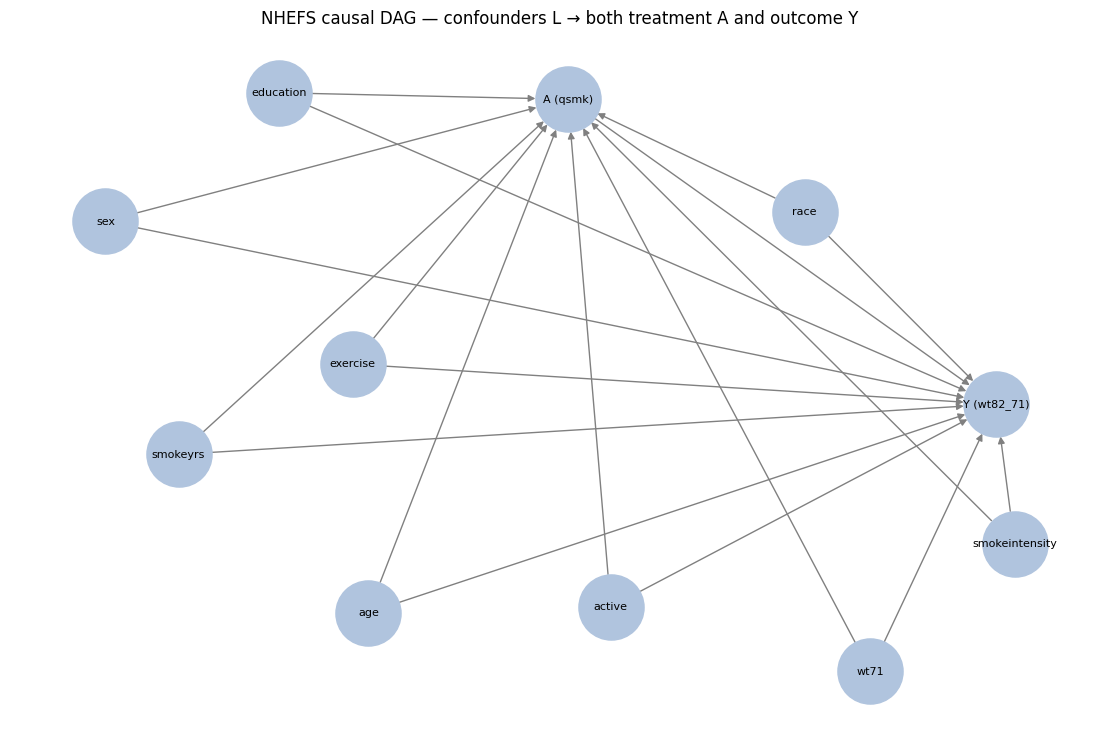

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
confounders = ['age', 'sex', 'race', 'education', 'smokeintensity',
               'smokeyrs', 'exercise', 'active', 'wt71']
G.add_node('A (qsmk)')
G.add_node('Y (wt82_71)')
G.add_edge('A (qsmk)', 'Y (wt82_71)')
for c in confounders:
    G.add_edge(c, 'A (qsmk)')
    G.add_edge(c, 'Y (wt82_71)')

pos = nx.spring_layout(G, seed=42, k=1.5)
plt.figure(figsize=(11,7))
nx.draw(G, pos, with_labels=True, node_size=2200, node_color='lightsteelblue',
        font_size=8, arrows=True, edge_color='gray')
plt.title("NHEFS causal DAG — confounders L → both treatment A and outcome Y")
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from causaldata import nhefs

df = nhefs.load_pandas().data
analytic = df.dropna(subset=['wt82_71']).copy()

# Cast categoricals
analytic['exercise_num']  = analytic['exercise'].astype(int)
analytic['active_num']    = analytic['active'].astype(int)
analytic['education_num'] = analytic['education'].astype(int)

# Build feature matrix — Hernán-Robins specification
X = pd.DataFrame({
    'sex':               analytic['sex'].astype(int),
    'race':              analytic['race'].astype(int),
    'age':               analytic['age'],
    'age_sq':            analytic['age']**2,
    'smokeintensity':    analytic['smokeintensity'],
    'smokeintensity_sq': analytic['smokeintensity']**2,
    'smokeyrs':          analytic['smokeyrs'],
    'smokeyrs_sq':       analytic['smokeyrs']**2,
    'wt71':              analytic['wt71'],
    'wt71_sq':           analytic['wt71']**2,
    'exercise_num':      analytic['exercise_num'],
    'active_num':        analytic['active_num'],
})
edu_dummies = pd.get_dummies(analytic['education_num'], prefix='edu',
                             drop_first=True).astype(int)
X = pd.concat([X, edu_dummies], axis=1)
y = analytic['qsmk'].astype(int)

# Fit UNPENALIZED logistic regression
#  - We want true propensities, not regularized estimates shrunk toward the prior
ps_model = LogisticRegression(penalty=None, max_iter=2000, solver='lbfgs')
ps_model.fit(X, y)

# Predicted propensities
analytic['propensity'] = ps_model.predict_proba(X)[:, 1]

# Summary
print(f"Features in propensity model: {X.shape[1]}\n")
print("Propensity score distribution (all subjects):")
print(analytic['propensity'].describe().round(3))
print("\nBy treatment group:")
print(analytic.groupby('qsmk')['propensity'].describe().round(3))

Features in propensity model: 16

Propensity score distribution (all subjects):
count    1566.000
mean        0.258
std         0.116
min         0.043
25%         0.177
50%         0.235
75%         0.318
max         0.793
Name: propensity, dtype: float64

By treatment group:
       count   mean    std    min    25%    50%    75%    max
qsmk                                                         
0.0   1163.0  0.240  0.106  0.043  0.167  0.221  0.296  0.679
1.0    403.0  0.309  0.129  0.055  0.215  0.278  0.384  0.793


C:\Users\shrik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.preprocessing import StandardScaler

# Same X as before
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ps_model = LogisticRegression(penalty=None, max_iter=5000, solver='lbfgs')
ps_model.fit(X_scaled, y)

# These propensities will be the converged ones
analytic['propensity'] = ps_model.predict_proba(X_scaled)[:, 1]

print(f"Converged: {ps_model.n_iter_[0]} iterations (limit was 5000)\n")
print("Propensity score distribution (all subjects):")
print(analytic['propensity'].describe().round(3))
print("\nBy treatment group:")
print(analytic.groupby('qsmk')['propensity'].describe().round(3))

Converged: 40 iterations (limit was 5000)

Propensity score distribution (all subjects):
count    1566.000
mean        0.257
std         0.115
min         0.045
25%         0.177
50%         0.237
75%         0.319
max         0.773
Name: propensity, dtype: float64

By treatment group:
       count   mean    std    min    25%    50%    75%    max
qsmk                                                         
0.0   1163.0  0.239  0.105  0.045  0.164  0.222  0.299  0.669
1.0    403.0  0.309  0.129  0.056  0.216  0.280  0.381  0.773


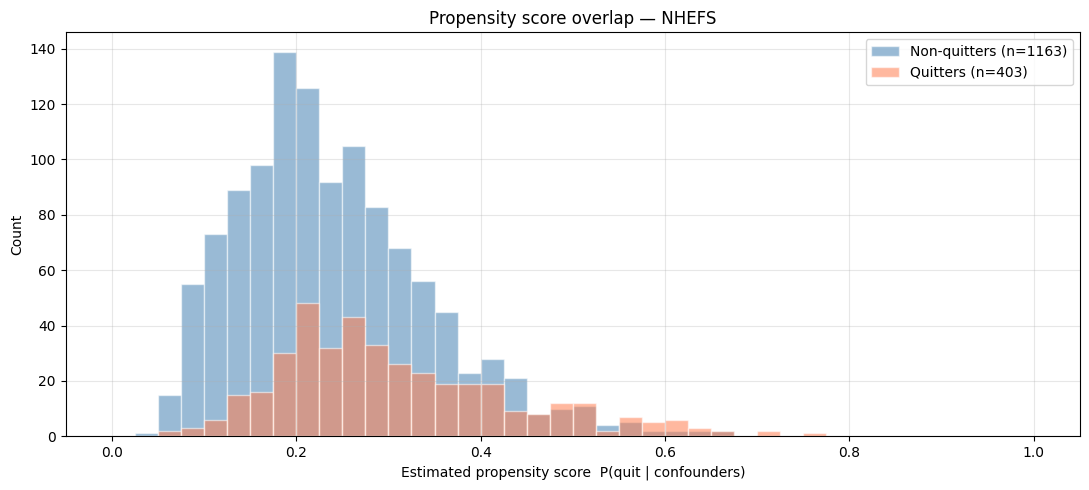

In [8]:
n0 = (analytic['qsmk'] == 0).sum()
n1 = (analytic['qsmk'] == 1).sum()

fig, ax = plt.subplots(figsize=(11, 5))
bins = np.linspace(0, 1, 41)
ax.hist(analytic.loc[analytic['qsmk']==0, 'propensity'], bins=bins,
        alpha=0.55, label=f'Non-quitters (n={n0})',
        color='steelblue', edgecolor='white')
ax.hist(analytic.loc[analytic['qsmk']==1, 'propensity'], bins=bins,
        alpha=0.55, label=f'Quitters (n={n1})',
        color='coral', edgecolor='white')
ax.set_xlabel('Estimated propensity score  P(quit | confounders)')
ax.set_ylabel('Count')
ax.set_title('Propensity score overlap — NHEFS')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
from scipy.spatial.distance import cdist

# 1) Transform to logit space
def logit(p):
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return np.log(p / (1 - p))

analytic['logit_ps'] = logit(analytic['propensity'])

# 2) Caliper at 0.2 * SD of logit propensity (Austin 2011)
caliper = 0.2 * analytic['logit_ps'].std()
print(f"Caliper (0.2 × SD of logit PS): {caliper:.4f}")

# 3) Separate groups (reset indices so positional matching works cleanly)
treated  = analytic[analytic['qsmk'] == 1].reset_index(drop=False)
controls = analytic[analytic['qsmk'] == 0].reset_index(drop=False)

# 4) Pairwise distance matrix: rows = treated, cols = controls
t_ps = treated['logit_ps'].values.reshape(-1, 1)
c_ps = controls['logit_ps'].values.reshape(-1, 1)
dist = cdist(t_ps, c_ps)

# 5) Greedy 1:1 nearest-neighbor matching WITHOUT replacement
#    Match hardest-first (most extreme propensities) — improves overall match quality
treated_order = np.argsort(-np.abs(treated['logit_ps'].values))
used = np.zeros(len(controls), dtype=bool)
pairs = []  # (treated_row, control_row, distance)

for t_i in treated_order:
    masked = dist[t_i].copy()
    masked[used] = np.inf
    c_i = int(np.argmin(masked))
    if masked[c_i] <= caliper:
        pairs.append((t_i, c_i, masked[c_i]))
        used[c_i] = True

# 6) Build matched dataset
t_idx = [p[0] for p in pairs]
c_idx = [p[1] for p in pairs]
matched_treated  = treated.iloc[t_idx].copy()
matched_controls = controls.iloc[c_idx].copy()
matched = pd.concat([matched_treated, matched_controls], ignore_index=True)

# 7) Report retention
n_t_total   = len(treated)
n_t_matched = len(t_idx)
n_dropped   = n_t_total - n_t_matched

print(f"\nMatching results:")
print(f"  Treated total:    {n_t_total}")
print(f"  Treated matched:  {n_t_matched}  ({n_t_matched/n_t_total*100:.1f}%)")
print(f"  Treated dropped:  {n_dropped}     ({n_dropped/n_t_total*100:.1f}%)")
print(f"  Final matched sample: {len(matched)} ({n_t_matched} treated + {n_t_matched} controls)")
print(f"\nMean logit-PS distance among matched pairs: {np.mean([p[2] for p in pairs]):.4f}")
print(f"Max logit-PS distance among matched pairs:  {np.max([p[2] for p in pairs]):.4f}")

Caliper (0.2 × SD of logit PS): 0.1251

Matching results:
  Treated total:    403
  Treated matched:  388  (96.3%)
  Treated dropped:  15     (3.7%)
  Final matched sample: 776 (388 treated + 388 controls)

Mean logit-PS distance among matched pairs: 0.0069
Max logit-PS distance among matched pairs:  0.1157


In [11]:
import numpy as np

def smd(x_treat, x_control):
    """Standardized Mean Difference (Cohen's d on covariates)."""
    m_t, m_c = x_treat.mean(), x_control.mean()
    v_t, v_c = x_treat.var(ddof=1), x_control.var(ddof=1)
    pooled = np.sqrt((v_t + v_c) / 2)
    return 0.0 if pooled == 0 else (m_t - m_c) / pooled

# Re-cast the matched sample's categoricals so SMD works
for d in (analytic, matched):
    if d['sex'].dtype.name == 'category':
        d['sex'] = d['sex'].astype(int)
    if d['race'].dtype.name == 'category':
        d['race'] = d['race'].astype(int)

confounders = ['age', 'sex', 'race', 'education_num',
               'smokeintensity', 'smokeyrs',
               'exercise_num', 'active_num', 'wt71']

rows = []
for c in confounders:
    # Before matching: full analytic sample
    t_before = analytic.loc[analytic['qsmk']==1, c].astype(float)
    n_before = analytic.loc[analytic['qsmk']==0, c].astype(float)
    # After matching: matched sample only
    t_after  = matched.loc[matched['qsmk']==1, c].astype(float)
    n_after  = matched.loc[matched['qsmk']==0, c].astype(float)
    rows.append({
        'variable':   c,
        'smd_before': smd(t_before, n_before),
        'smd_after':  smd(t_after,  n_after),
    })

balance = pd.DataFrame(rows)
balance['abs_before'] = balance['smd_before'].abs()
balance['abs_after']  = balance['smd_after'].abs()

print(balance.round(3).to_string(index=False))
print(f"\nMax |SMD| before: {balance['abs_before'].max():.3f}")
print(f"Max |SMD| after:  {balance['abs_after'].max():.3f}")
print(f"Vars with |SMD| > 0.10 before: {(balance['abs_before'] > 0.10).sum()}/{len(balance)}")
print(f"Vars with |SMD| > 0.10 after:  {(balance['abs_after']  > 0.10).sum()}/{len(balance)}")

      variable  smd_before  smd_after  abs_before  abs_after
           age       0.282     -0.005       0.282      0.005
           sex      -0.160      0.031       0.160      0.031
          race      -0.177      0.018       0.177      0.018
 education_num       0.088      0.025       0.088      0.025
smokeintensity      -0.217     -0.025       0.217      0.025
      smokeyrs       0.159     -0.006       0.159      0.006
  exercise_num       0.104     -0.025       0.104      0.025
    active_num       0.089     -0.074       0.089      0.074
          wt71       0.133      0.021       0.133      0.021

Max |SMD| before: 0.282
Max |SMD| after:  0.074
Vars with |SMD| > 0.10 before: 7/9
Vars with |SMD| > 0.10 after:  0/9


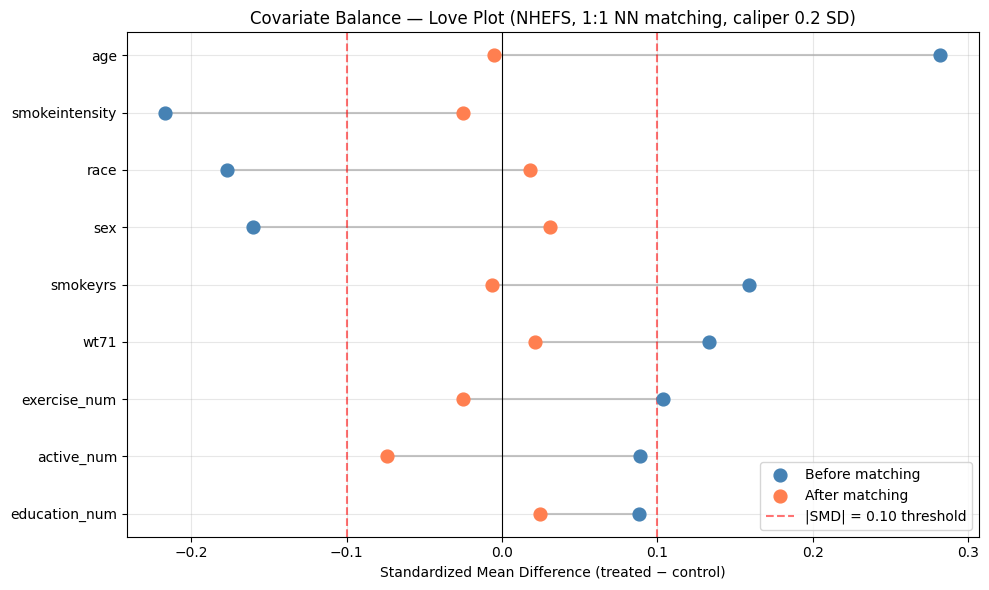

In [12]:
import matplotlib.pyplot as plt

bs = balance.sort_values('abs_before', ascending=True).reset_index(drop=True)
y_pos = np.arange(len(bs))

fig, ax = plt.subplots(figsize=(10, 6))
# Connector lines (before → after)
for i in y_pos:
    ax.plot([bs.loc[i, 'smd_before'], bs.loc[i, 'smd_after']],
            [i, i], color='gray', alpha=0.45, zorder=1)
ax.scatter(bs['smd_before'], y_pos, label='Before matching',
           color='steelblue', s=85, zorder=3)
ax.scatter(bs['smd_after'],  y_pos, label='After matching',
           color='coral',     s=85, zorder=3)

# Reference lines
ax.axvline(0,     color='black', linewidth=0.8)
ax.axvline( 0.10, color='red', linestyle='--', alpha=0.55,
            label='|SMD| = 0.10 threshold')
ax.axvline(-0.10, color='red', linestyle='--', alpha=0.55)

ax.set_yticks(y_pos)
ax.set_yticklabels(bs['variable'])
ax.set_xlabel('Standardized Mean Difference (treated − control)')
ax.set_title('Covariate Balance — Love Plot (NHEFS, 1:1 NN matching, caliper 0.2 SD)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
import numpy as np
from scipy import stats

# matched_treated and matched_controls are aligned by row — each i is a pair
y_t = matched_treated['wt82_71'].values
y_c = matched_controls['wt82_71'].values
diffs = y_t - y_c

# Point estimate
att = diffs.mean()
print(f"Matched ATT = {att:+.3f} kg\n")
print(f"  Matched quitters     mean Δweight: {y_t.mean():+.3f} kg")
print(f"  Matched non-quitters mean Δweight: {y_c.mean():+.3f} kg")
print(f"  Difference (ATT):                  {att:+.3f} kg\n")

# Paired t-test CI
ci_lo_t, ci_hi_t = stats.t.interval(0.95, df=len(diffs)-1,
                                     loc=att, scale=stats.sem(diffs))
_, p_paired = stats.ttest_rel(y_t, y_c)
print("Paired t-test:")
print(f"  95% CI:  [{ci_lo_t:+.3f}, {ci_hi_t:+.3f}] kg")
print(f"  p-value: {p_paired:.6f}\n")

# Pair-level bootstrap CI
rng = np.random.default_rng(42)
n_boot = 5000
boot = np.empty(n_boot)
for i in range(n_boot):
    idx = rng.integers(0, len(diffs), size=len(diffs))
    boot[i] = diffs[idx].mean()
print("Bootstrap (5000 reps, paired resampling):")
print(f"  95% CI: [{np.percentile(boot, 2.5):+.3f}, {np.percentile(boot, 97.5):+.3f}] kg\n")

# The story
print("─" * 50)
print("THE STORY")
print("─" * 50)
print(f"  Naive 'effect' (unadjusted): +2.541 kg")
print(f"  Causal ATT (PSM matched):    {att:+.3f} kg")
print(f"  Confounding bias removed:    {att - 2.541:+.3f} kg")
print(f"  Hernán-Robins canonical:     ~+3.4 to +3.5 kg")

Matched ATT = +3.270 kg

  Matched quitters     mean Δweight: +4.665 kg
  Matched non-quitters mean Δweight: +1.395 kg
  Difference (ATT):                  +3.270 kg

Paired t-test:
  95% CI:  [+2.127, +4.414] kg
  p-value: 0.000000

Bootstrap (5000 reps, paired resampling):
  95% CI: [+2.111, +4.427] kg

──────────────────────────────────────────────────
THE STORY
──────────────────────────────────────────────────
  Naive 'effect' (unadjusted): +2.541 kg
  Causal ATT (PSM matched):    +3.270 kg
  Confounding bias removed:    +0.729 kg
  Hernán-Robins canonical:     ~+3.4 to +3.5 kg


In [14]:
from dowhy import CausalModel

# --- Step 1 of 4: MODEL ---
# Pre-clean: DoWhy needs numeric columns, no Categoricals
analytic_dw = analytic.copy()
for col in ['sex', 'race', 'education', 'exercise', 'active']:
    if analytic_dw[col].dtype.name == 'category':
        analytic_dw[col] = analytic_dw[col].astype(int)

common_causes = ['age', 'sex', 'race', 'education',
                 'smokeintensity', 'smokeyrs',
                 'exercise', 'active', 'wt71']

model = CausalModel(
    data         = analytic_dw,
    treatment    = 'qsmk',
    outcome      = 'wt82_71',
    common_causes= common_causes
)

# --- Step 2 of 4: IDENTIFY ---
# DoWhy uses do-calculus to derive the identifying expression automatically
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print("=" * 60)
print("STEP 2 — IDENTIFICATION")
print("=" * 60)
print(identified_estimand)

# --- Step 3 of 4: ESTIMATE ---
estimate = model.estimate_effect(
    identified_estimand,
    method_name   = 'backdoor.propensity_score_matching',
    target_units  = 'att',   # ATT to match our manual analysis
    method_params = {'random_state': 42}
)
print("=" * 60)
print("STEP 3 — ESTIMATION")
print("=" * 60)
print(f"DoWhy PSM ATT estimate: {estimate.value:+.3f} kg")
print(f"Your manual PSM ATT:    +3.270 kg")

STEP 2 — IDENTIFICATION
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                                                    
───────(E[wt_82_71|education,wt71,sex,smokeyrs,age,smokeintensity,exercise,active,race])
d[qsmk]                                                                                 
Estimand assumption 1, Unconfoundedness: If U→{qsmk} and U→wt82_71 then P(wt82_71|qsmk,education,wt71,sex,smokeyrs,age,smokeintensity,exercise,active,race,U) = P(wt82_71|qsmk,education,wt71,sex,smokeyrs,age,smokeintensity,exercise,active,race)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
   d                                                                                    
───────(E[wt_82_71|race,wt71,sex,age,smokeyrs,smokeintensity,

C:\Users\shrik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', message='.*lbfgs.*')

print("=" * 60)
print("STEP 4 — REFUTATION TESTS")
print("=" * 60)

# Refuter 1: Placebo treatment
# Replace qsmk with a random permutation. A valid causal estimator
# should find ~zero effect when the "treatment" is random noise.
print("\n--- Refuter 1: Placebo Treatment (should give ~0) ---")
refute_placebo = model.refute_estimate(
    identified_estimand, estimate,
    method_name='placebo_treatment_refuter',
    placebo_type='permute',
    num_simulations=100,
    random_seed=42
)
print(refute_placebo)

# Refuter 2: Random common cause
# Add a random variable as if it were a confounder. A robust method
# should give nearly the same estimate (it's already controlling for
# the real confounders; adding noise shouldn't matter).
print("\n--- Refuter 2: Random Common Cause (should be ~unchanged) ---")
refute_rcc = model.refute_estimate(
    identified_estimand, estimate,
    method_name='random_common_cause',
    num_simulations=100,
    random_seed=42
)
print(refute_rcc)

# Refuter 3: Data subset
# Re-run on random 80% subsets. The estimate should be similar
# (effect is a real population parameter, not an artifact of these
# particular subjects).
print("\n--- Refuter 3: Data Subset 80% (should be ~unchanged) ---")
refute_subset = model.refute_estimate(
    identified_estimand, estimate,
    method_name='data_subset_refuter',
    subset_fraction=0.8,
    num_simulations=100,
    random_seed=42
)
print(refute_subset)

STEP 4 — REFUTATION TESTS

--- Refuter 1: Placebo Treatment (should give ~0) ---
Refute: Use a Placebo Treatment
Estimated effect:2.0420191625062034
New effect:0.05582764668709684
p value:0.94


--- Refuter 2: Random Common Cause (should be ~unchanged) ---
Refute: Add a random common cause
Estimated effect:2.0420191625062034
New effect:2.042019162506203
p value:1.0


--- Refuter 3: Data Subset 80% (should be ~unchanged) ---
Refute: Use a subset of data
Estimated effect:2.0420191625062034
New effect:2.23745074842526
p value:0.74



In [16]:
import statsmodels.api as sm

# Build outcome-model design matrix
# Same nine confounders as the propensity model, plus the treatment qsmk,
# plus the Hernán-Robins quadratic terms (outcome model also benefits from
# flexibility because residual confounding shows up here)
X_out = pd.DataFrame({
    'qsmk':              analytic['qsmk'].astype(int),
    'sex':               analytic['sex'].astype(int),
    'race':              analytic['race'].astype(int),
    'age':               analytic['age'],
    'age_sq':            analytic['age']**2,
    'smokeintensity':    analytic['smokeintensity'],
    'smokeintensity_sq': analytic['smokeintensity']**2,
    'smokeyrs':          analytic['smokeyrs'],
    'smokeyrs_sq':       analytic['smokeyrs']**2,
    'wt71':              analytic['wt71'],
    'wt71_sq':           analytic['wt71']**2,
    'exercise_num':      analytic['exercise_num'],
    'active_num':        analytic['active_num'],
})
edu_dummies = pd.get_dummies(analytic['education_num'], prefix='edu',
                             drop_first=True).astype(int)
X_out = pd.concat([X_out, edu_dummies], axis=1)
X_out = sm.add_constant(X_out)
y_out = analytic['wt82_71'].values

# --- Step 1: Fit the outcome model ---
outcome_model = sm.OLS(y_out, X_out).fit()
print("Outcome-model R²:", round(outcome_model.rsquared, 4))
print("Coefficient on qsmk (raw, no counterfactual prediction):",
      round(outcome_model.params['qsmk'], 3))

# --- Step 2: Predict counterfactuals ---
# Counterfactual A=1: set qsmk=1 for everyone
X_treat = X_out.copy(); X_treat['qsmk'] = 1
y_hat_treat = outcome_model.predict(X_treat).values

# Counterfactual A=0: set qsmk=0 for everyone
X_ctrl  = X_out.copy(); X_ctrl['qsmk'] = 0
y_hat_ctrl  = outcome_model.predict(X_ctrl).values

# --- Step 3: Compute ATE and ATT ---
ate_gcomp = (y_hat_treat - y_hat_ctrl).mean()

treated_mask = (analytic['qsmk'] == 1).values
att_gcomp = (y_hat_treat[treated_mask] - y_hat_ctrl[treated_mask]).mean()

print(f"\nG-computation ATE (whole population): {ate_gcomp:+.3f} kg")
print(f"G-computation ATT (treated subset):    {att_gcomp:+.3f} kg")

# --- Bootstrap CI for the ATT ---
rng = np.random.default_rng(42)
n_boot = 500
boot = np.empty(n_boot)
for i in range(n_boot):
    idx = rng.integers(0, len(analytic), size=len(analytic))
    bX = X_out.iloc[idx].reset_index(drop=True)
    by = y_out[idx]
    bm = sm.OLS(by, bX).fit()
    bX1 = bX.copy(); bX1['qsmk'] = 1
    bX0 = bX.copy(); bX0['qsmk'] = 0
    bp1 = bm.predict(bX1).values
    bp0 = bm.predict(bX0).values
    bt = (bX['qsmk'] == 1).values
    boot[i] = (bp1[bt] - bp0[bt]).mean() if bt.sum() else np.nan

boot = boot[~np.isnan(boot)]
print(f"  Bootstrap 95% CI (ATT, {len(boot)} reps): "
      f"[{np.percentile(boot, 2.5):+.3f}, "
      f"{np.percentile(boot, 97.5):+.3f}] kg")

# --- The convergence check ---
print("\n" + "─" * 50)
print("METHOD CONVERGENCE")
print("─" * 50)
print(f"  Manual PSM ATT:        +3.270 kg  (CI 2.11 to 4.43)")
print(f"  G-computation ATT:     {att_gcomp:+.3f} kg")
print(f"  Hernán-Robins (IPW):   ~+3.4 to +3.5 kg")

Outcome-model R²: 0.1455
Coefficient on qsmk (raw, no counterfactual prediction): 3.473

G-computation ATE (whole population): +3.473 kg
G-computation ATT (treated subset):    +3.473 kg
  Bootstrap 95% CI (ATT, 500 reps): [+2.577, +4.438] kg

──────────────────────────────────────────────────
METHOD CONVERGENCE
──────────────────────────────────────────────────
  Manual PSM ATT:        +3.270 kg  (CI 2.11 to 4.43)
  G-computation ATT:     +3.473 kg
  Hernán-Robins (IPW):   ~+3.4 to +3.5 kg
